# 🏏 IPL DATA ANALYSIS 

-----

## 🎯 Objectives

- Understand the structure of the IPL dataset.
- Perform data cleaning and preprocessing.
- Analyze team and player performances.
- Explore toss decisions and their impact on match results.
- Identify winning trends across teams and venues.
- Create insightful visualizations to support findings.

---

## 🛠️ Libraries Used

- Pandas
- NumPy
- Matplotlib
- Seaborn

---

In [58]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')


In [59]:
df = pd.read_csv('IPL.csv')
df.head()

,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,second_ings_score,second_ings_wkts,match_winner,won_by,margin,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure
0,1,"March 26,2022","Wankhede Stadium, Mumbai",Chennai,Kolkata,Group,Kolkata,Field,131,5,133,4,Kolkata,Wickets,6,Umesh Yadav,MS Dhoni,50,Dwayne Bravo,3--20
1,2,"March 27,2022","Brabourne Stadium, Mumbai",Delhi,Mumbai,Group,Delhi,Field,177,5,179,6,Delhi,Wickets,4,Kuldeep Yadav,Ishan Kishan,81,Kuldeep Yadav,3--18
2,3,"March 27,2022","Dr DY Patil Sports Academy, Mumbai",Banglore,Punjab,Group,Punjab,Field,205,2,208,5,Punjab,Wickets,5,Odean Smith,Faf du Plessis,88,Mohammed Siraj,2--59
3,4,"March 28,2022","Wankhede Stadium, Mumbai",Gujarat,Lucknow,Group,Gujarat,Field,158,6,161,5,Gujarat,Wickets,5,Mohammed Shami,Deepak Hooda,55,Mohammed Shami,3--25
4,5,"March 29,2022","Maharashtra Cricket Association Stadium,Pune",Hyderabad,Rajasthan,Group,Hyderabad,Field,210,6,149,7,Rajasthan,Runs,61,Sanju Samson,Aiden Markram,57,Yuzvendra Chahal,3--22


In [60]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74 entries, 0 to 73
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   match_id             74 non-null     int64 
 1   date                 74 non-null     object
 2   venue                74 non-null     object
 3   team1                74 non-null     object
 4   team2                74 non-null     object
 5   stage                74 non-null     object
 6   toss_winner          74 non-null     object
 7   toss_decision        74 non-null     object
 8   first_ings_score     74 non-null     int64 
 9   first_ings_wkts      74 non-null     int64 
 10  second_ings_score    74 non-null     int64 
 11  second_ings_wkts     74 non-null     int64 
 12  match_winner         74 non-null     object
 13  won_by               74 non-null     object
 14  margin               74 non-null     int64 
 15  player_of_the_match  74 non-null     object
 16  top_scorer

In [61]:
df.describe()

,match_id,first_ings_score,first_ings_wkts,second_ings_score,second_ings_wkts,margin,highscore
count,74.000000,74.000000,74.000000,74.000000,74.000000,74.000000,74.000000
mean,37.500000,171.121622,6.135135,158.540541,6.175676,16.972973,71.716216
std,21.505813,29.048355,2.222699,29.299207,2.639832,19.651047,20.705052
min,1.000000,68.000000,0.000000,72.000000,1.000000,2.000000,28.000000
25%,19.250000,154.250000,5.000000,142.750000,4.000000,5.250000,57.000000
50%,37.500000,169.500000,6.000000,160.000000,6.000000,8.000000,68.000000
75%,55.750000,192.750000,8.000000,176.000000,8.000000,18.000000,87.750000
max,74.000000,222.000000,10.000000,211.000000,10.000000,91.000000,140.000000


In [62]:
df.shape

(74, 20)

In [63]:
df.isna().sum()

match_id               0
date                   0
venue                  0
team1                  0
team2                  0
stage                  0
toss_winner            0
toss_decision          0
first_ings_score       0
first_ings_wkts        0
second_ings_score      0
second_ings_wkts       0
match_winner           0
won_by                 0
margin                 0
player_of_the_match    0
top_scorer             0
highscore              0
best_bowling           0
best_bowling_figure    0
dtype: int64

### 1. Which team won the most of the matches?


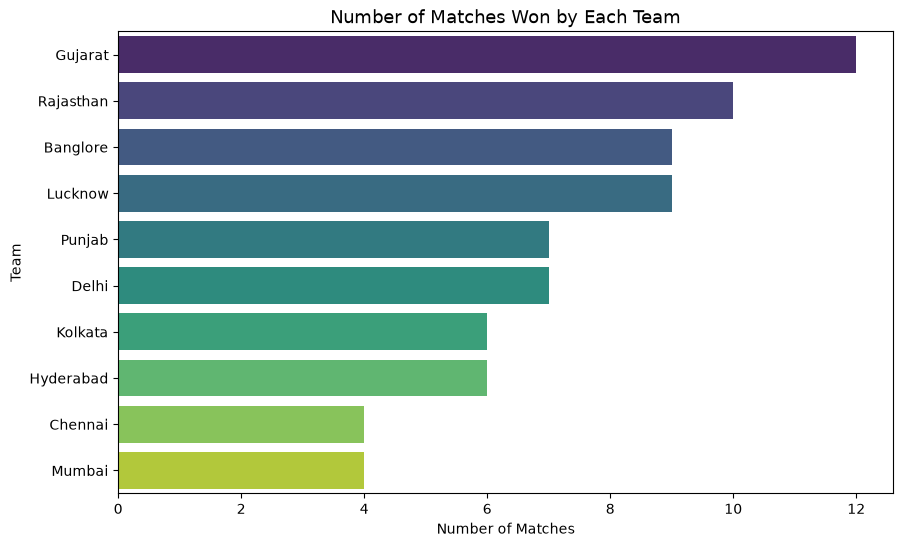

In [84]:

plt.figure(figsize=(10,6))
match_win = df['match_winner'].value_counts()

sns.barplot(x=match_win.values, y=match_win.index, palette='viridis')

plt.title('Number of Matches Won by Each Team', fontsize=13)
plt.xlabel('Number of Matches')
plt.ylabel('Team')
plt.savefig('images/matches_won_by_each_team.png', dpi=300, bbox_inches='tight')

### 2. Toss Decision Trends

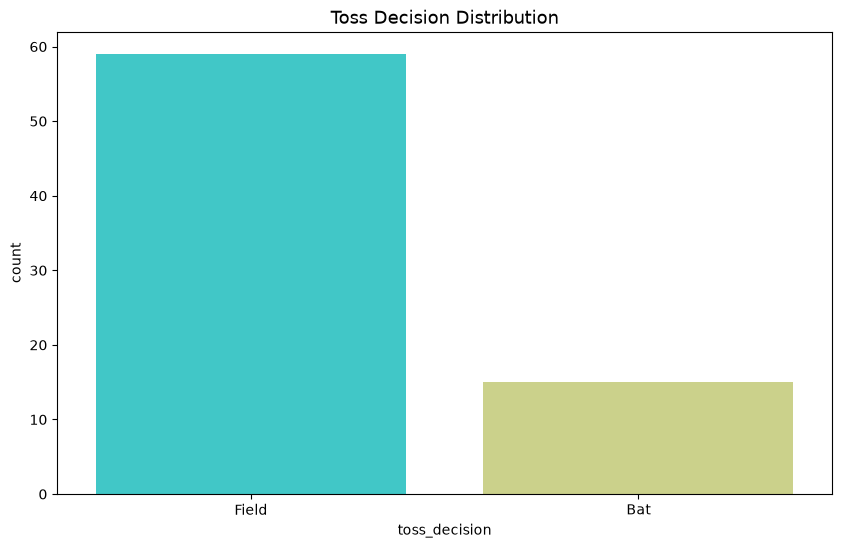

In [85]:

plt.figure(figsize=(10,6))
sns.countplot(x='toss_decision', data=df, palette='rainbow')
plt.title('Toss Decision Distribution', fontsize=13)

plt.savefig('images/toss_decision_distribution.png', dpi=300, bbox_inches='tight')

### 3. Toss winner vs match winner

In [66]:
count= df[ df['toss_winner']==df['match_winner'] ]['match_id'].count()
count

np.int64(36)

In [67]:
percentage =(count*100)/df.shape[0]
percentage.round(2)

np.float64(48.65)

### 4.how do teams wins? (run or wickets)

In [68]:
df.head()

,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,second_ings_score,second_ings_wkts,match_winner,won_by,margin,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure
0,1,"March 26,2022","Wankhede Stadium, Mumbai",Chennai,Kolkata,Group,Kolkata,Field,131,5,133,4,Kolkata,Wickets,6,Umesh Yadav,MS Dhoni,50,Dwayne Bravo,3--20
1,2,"March 27,2022","Brabourne Stadium, Mumbai",Delhi,Mumbai,Group,Delhi,Field,177,5,179,6,Delhi,Wickets,4,Kuldeep Yadav,Ishan Kishan,81,Kuldeep Yadav,3--18
2,3,"March 27,2022","Dr DY Patil Sports Academy, Mumbai",Banglore,Punjab,Group,Punjab,Field,205,2,208,5,Punjab,Wickets,5,Odean Smith,Faf du Plessis,88,Mohammed Siraj,2--59
3,4,"March 28,2022","Wankhede Stadium, Mumbai",Gujarat,Lucknow,Group,Gujarat,Field,158,6,161,5,Gujarat,Wickets,5,Mohammed Shami,Deepak Hooda,55,Mohammed Shami,3--25
4,5,"March 29,2022","Maharashtra Cricket Association Stadium,Pune",Hyderabad,Rajasthan,Group,Hyderabad,Field,210,6,149,7,Rajasthan,Runs,61,Sanju Samson,Aiden Markram,57,Yuzvendra Chahal,3--22


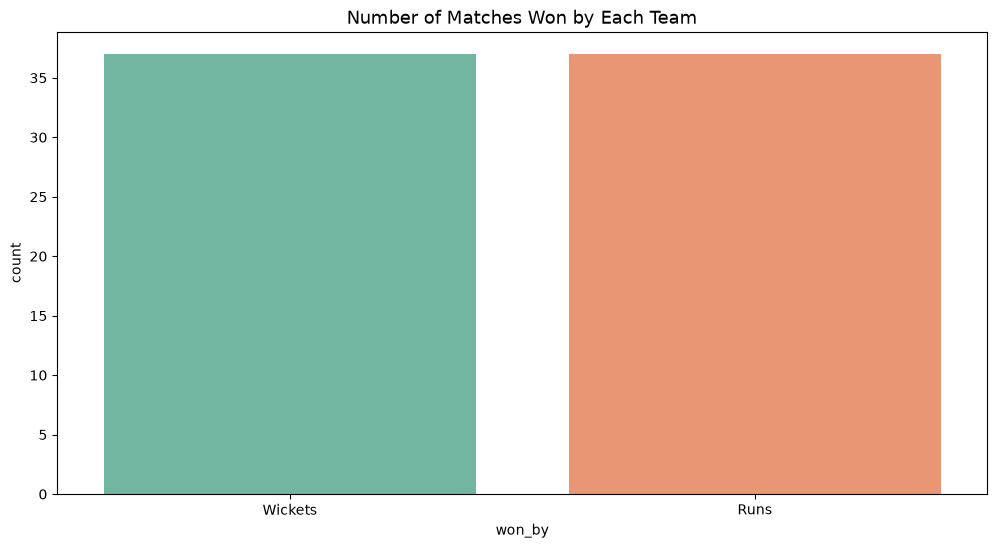

In [86]:
plt.figure(figsize=(12,6))
sns.countplot(x='won_by', data=df, palette='Set2')
plt.title('Number of Matches Won by Each Team', fontsize=13)

plt.savefig('images/matches_won_by_each_team.png', dpi=300, bbox_inches='tight')

### key Player performances

#### 1. most 'player of the match' Award

In [70]:
df.head()

,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,second_ings_score,second_ings_wkts,match_winner,won_by,margin,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure
0,1,"March 26,2022","Wankhede Stadium, Mumbai",Chennai,Kolkata,Group,Kolkata,Field,131,5,133,4,Kolkata,Wickets,6,Umesh Yadav,MS Dhoni,50,Dwayne Bravo,3--20
1,2,"March 27,2022","Brabourne Stadium, Mumbai",Delhi,Mumbai,Group,Delhi,Field,177,5,179,6,Delhi,Wickets,4,Kuldeep Yadav,Ishan Kishan,81,Kuldeep Yadav,3--18
2,3,"March 27,2022","Dr DY Patil Sports Academy, Mumbai",Banglore,Punjab,Group,Punjab,Field,205,2,208,5,Punjab,Wickets,5,Odean Smith,Faf du Plessis,88,Mohammed Siraj,2--59
3,4,"March 28,2022","Wankhede Stadium, Mumbai",Gujarat,Lucknow,Group,Gujarat,Field,158,6,161,5,Gujarat,Wickets,5,Mohammed Shami,Deepak Hooda,55,Mohammed Shami,3--25
4,5,"March 29,2022","Maharashtra Cricket Association Stadium,Pune",Hyderabad,Rajasthan,Group,Hyderabad,Field,210,6,149,7,Rajasthan,Runs,61,Sanju Samson,Aiden Markram,57,Yuzvendra Chahal,3--22


In [71]:
counts= df['player_of_the_match'].value_counts().head(10)
counts

player_of_the_match
Kuldeep Yadav        4
Jos Buttler          3
Wanindu Hasaranga    2
Umesh Yadav          2
Quinton de Kock      2
Shubman Gill         2
Avesh Khan           2
Dinesh Karthik       2
Hardik Pandya        2
Rahul Tripathi       2
Name: count, dtype: int64

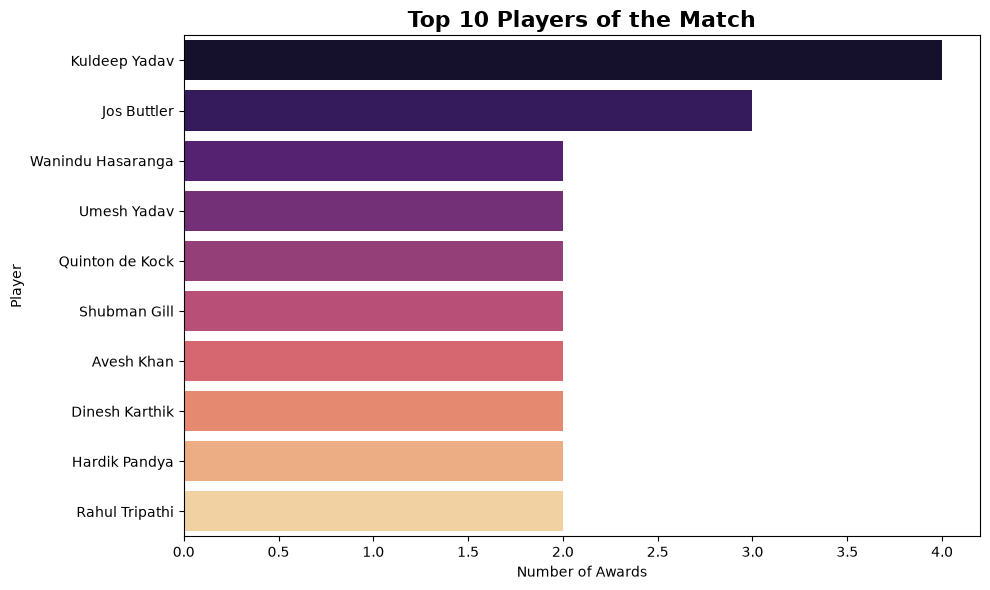

In [80]:
plt.figure(figsize=(10,6))

sns.barplot(
    y=counts.index,
    x=counts.values,
    palette="magma"
)

plt.title("Top 10 Players of the Match", fontsize=16, fontweight="bold")
plt.xlabel("Number of Awards")
plt.ylabel("Player")

plt.tight_layout()

# Save the graph
plt.savefig("images/top_10_players_of_the_match.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

#### 2.Top 2 high Scorers

In [92]:
top2= df.groupby('top_scorer')['highscore'].sum().sort_values(ascending=False).head(2)
top2

top_scorer
Jos Buttler        651
Quinton de Kock    377
Name: highscore, dtype: int64

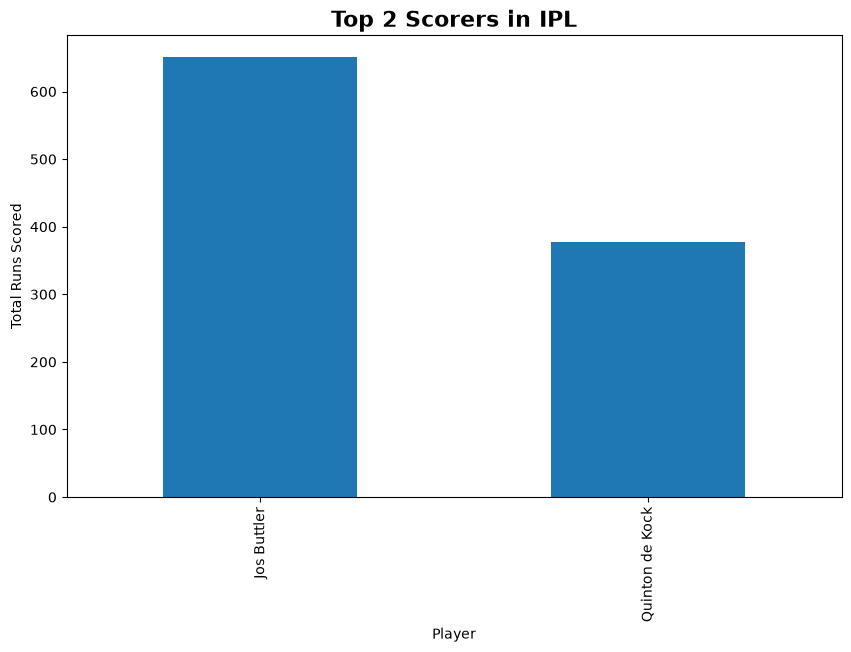

In [95]:
plt.figure(figsize=(10,6))

top2.plot(kind='bar')

plt.title("Top 2 Scorers in IPL", fontsize=16, fontweight="bold")
plt.xlabel("Player")
plt.ylabel("Total Runs Scored")

plt.savefig('images/top_2_scorers_in_ipl.png', dpi=300, bbox_inches='tight')

#### 3. 10 best bowling figure

In [106]:
df['highest_wicket']= df['best_bowling_figure'].apply(lambda x: x.split('--')[0])
df['highest_wicket']=df['highest_wicket'].astype(int)

topbowler =df.groupby('best_bowling')['highest_wicket'].sum().sort_values(ascending =False).head(10)
topbowler

best_bowling
Yuzvendra Chahal     17
Jasprit Bumrah       11
Kuldeep Yadav        11
Rashid Khan          11
Josh Hazlewood       10
Kagiso Rabada        10
Avesh Khan           10
Umran Malik           9
Wanindu Hasaranga     9
T Natarajan           8
Name: highest_wicket, dtype: int64

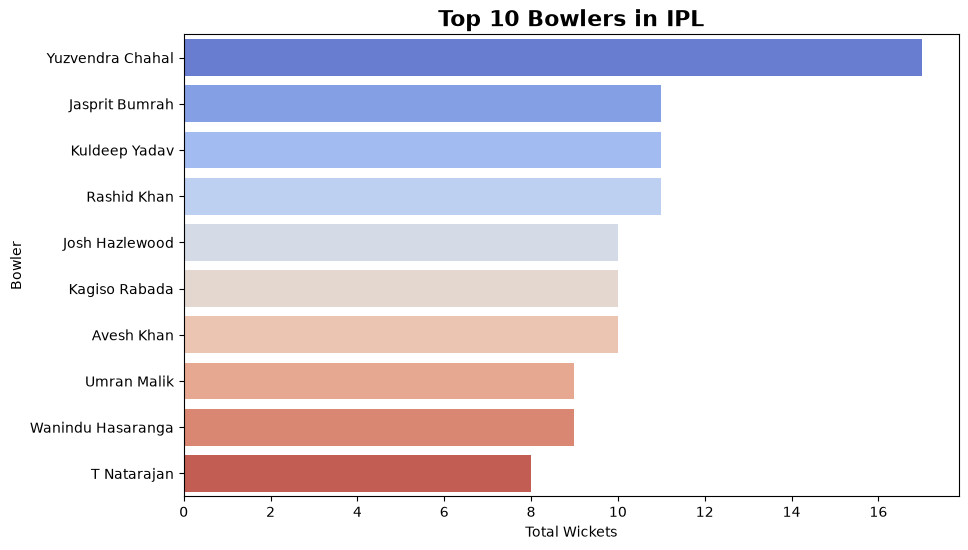

In [113]:
plt.figure(figsize=(10,6))
sns.barplot( x=topbowler.values, y=topbowler.index, palette='coolwarm')
plt.xlabel('Total Wickets')
plt.title('Top 10 Bowlers in IPL', fontsize=16, fontweight="bold")
plt.ylabel('Bowler')

plt.savefig('images/top_10_bowlers_in_ipl.png', dpi=300, bbox_inches='tight')

### 4. most matches played by venue

In [121]:
venue_count= df['venue'].value_counts()
venue_count

venue
Wankhede Stadium, Mumbai                        21
Dr DY Patil Sports Academy, Mumbai              20
Brabourne Stadium, Mumbai                       16
Maharashtra Cricket Association Stadium,Pune    13
Eden Gardens, Kolkata                            2
Narendra Modi Stadium, Ahmedabad                 2
Name: count, dtype: int64

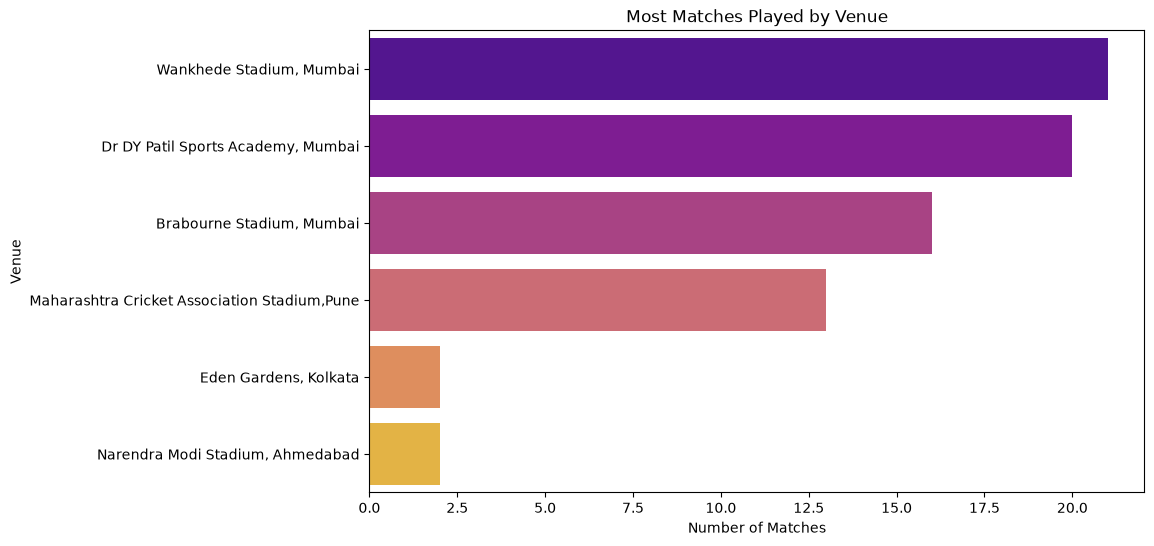

In [120]:
plt.figure(figsize=(10,6))
sns.barplot(x=venue_count.values, y=venue_count.index, palette='plasma')
plt.xlabel('Number of Matches')
plt.ylabel('Venue')
plt.title('Most Matches Played by Venue')

plt.savefig('images/most_matches_played_by_venue.png', dpi=300, bbox_inches='tight')

### custom questions and insights

#### 1. who won the highest margin by runs?

In [133]:
run = df[df['won_by']=='Runs']
run.head()

,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,...,second_ings_wkts,match_winner,won_by,margin,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure,highest_wicket
4,5,"March 29,2022","Maharashtra Cricket Association Stadium,Pune",Hyderabad,Rajasthan,Group,Hyderabad,Field,210,6,...,7,Rajasthan,Runs,61,Sanju Samson,Aiden Markram,57,Yuzvendra Chahal,3--22,3
8,9,"April 2,2022","Dr DY Patil Sports Academy, Mumbai",Mumbai,Rajasthan,Group,Mumbai,Field,193,8,...,8,Rajasthan,Runs,23,Jos Buttler,Jos Buttler,100,Jasprit Bumrah,3--17,3
9,10,"April 2,2022","Maharashtra Cricket Association Stadium,Pune",Delhi,Gujarat,Group,Delhi,Field,171,6,...,9,Gujarat,Runs,14,Lockie Ferguson,Shubman Gill,84,Lockie Ferguson,4--28,4
10,11,"April 3,2022","Brabourne Stadium, Mumbai",Chennai,Punjab,Group,Chennai,Field,180,8,...,10,Punjab,Runs,54,Liam Livingstone,Liam Livingstone,60,Rahul Chahar,3--25,3
11,12,"April 4,2022","Dr DY Patil Sports Academy, Mumbai",Hyderabad,Lucknow,Group,Hyderabad,Field,169,7,...,9,Lucknow,Runs,12,Avesh Khan,KL Rahul,68,Avesh Khan,4--24,4


In [136]:
run[run['margin'] == run['margin'].max()] [['match_winner', 'player_of_the_match','margin']]

,match_winner,player_of_the_match,margin
54,Chennai,Devon Conway,91


#### 2. which player has a highest individual score?

In [138]:
df[ df['highscore'] == df['highscore'].max()] [['top_scorer', 'highscore','match_winner']]

,top_scorer,highscore,match_winner
65,Quinton de Kock,140,Lucknow


#### 3. which blower had the best bowling figure ?

In [142]:
df[ df['highest_wicket']== df['highest_wicket'].max()] [['best_bowling', 'best_bowling_figure']]

,best_bowling,best_bowling_figure
29,Yuzvendra Chahal,5--40
39,Umran Malik,5--25
53,Wanindu Hasaranga,5--18
55,Jasprit Bumrah,5--10


# 📌 Conclusion

This exploratory data analysis provided valuable insights into IPL matches by examining team performances, player achievements, toss decisions, venues, and match outcomes.

Key findings include:
- Identified the most successful teams based on match victories.
- Analyzed the impact of winning the toss on match results.
- Explored the distribution of Player of the Match awards.
- Compared performances across different venues and seasons.
- Visualized important trends using statistical charts.

Overall, this project demonstrates how Python can be used for cleaning, analyzing, and visualizing real-world sports datasets to extract meaningful insights.

Future improvements may include building predictive models to forecast match winners and creating interactive dashboards using Plotly or Power BI.